In [1]:
%load_ext autoreload
%autoreload 2

# load general packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gumbel_r

# load modules related to this exercise
import simple_zurcher as model

In [2]:
# Create a function that plots the value and policy functions (for later)
def plot_solution(par, sol):

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(par.grid, sol.V)
    ax[0].set_title('Value function')
    ax[0].set_xlabel('milage')
    
    ax[1].plot(par.grid, sol.pk)
    ax[1].set_title('Probability of keeping')
    ax[1].set_xlabel('milage')
    ax[1].yaxis.set_major_formatter('{x:.0%}')

## Exercise 1 - Deterministic state transition

Consider the engine replacement model, with Bellman equation given by:

$$
V(x) = \max_{d\in \{0,1\}} \big\{ u(x,d) + \beta V(x') \big\} \\
$$

Where the state transition is deterministically given by:
$$
x'=\left \{
\begin{array}{ll}
    x + 1 & \text{if }d=\text{keep}=0 \\
    1 & \text{if }d=\text{replace}=1
\end{array} \right.
$$

utility is given by:

$$
u(x,d)=\left \{
\begin{array}{ll}
    -c(x) & \text{if }d=\text{keep}=0 \\
    -RC-c(0) & \text{if }d=\text{replace}=1
\end{array} \right.
$$

Here

- $ x $ = milage of the engine
- $ RC $ = replacement cost  
- $ c(x) = c \cdot x $ = cost of maintenance





##### a) Orient yourself with the objects in the function $\texttt{setup}$, $\texttt{solve\_SA}$, $\texttt{bellman}$, $\texttt{util}$, and $\texttt{cost}$ in $\texttt{simple\_zurcher.py}$.

##### b) Fill in the missing stuff in the $\texttt{bellman}$ and $\texttt{EV\_deterministic}$ functions. Solve the model. Plot the solution. Why is the value function flat at high mileage?
In the *bellman* function, you don't have to fill in code for *taste_shocks* other than for *taste_shocks == 'None'*.

**Answer.** Once mileage is high enough, replacement is optimal. Replacement resets next period's mileage, so the value no longer depends on the current high-mileage state; this makes the value function flat in that region.

In [3]:
par = model.setup()
sol = model.solve_SA(par)

Finished after 1738 iterations
Convergence achieved: True


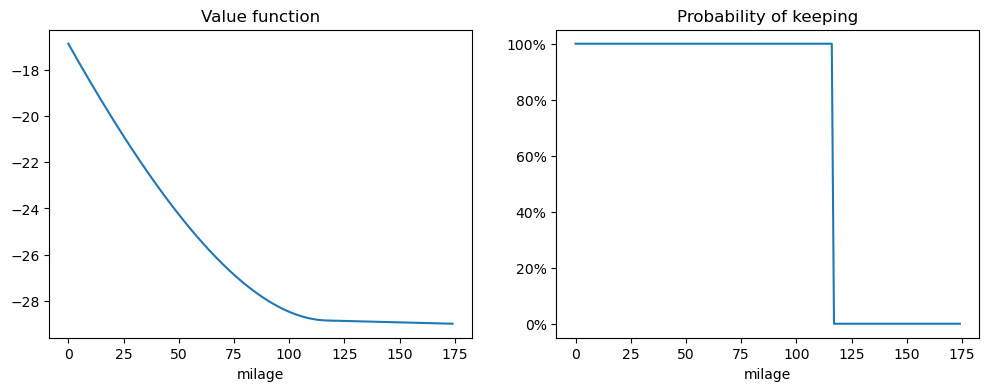

In [4]:
plot_solution(par, sol)

##### c) When is it optimal to replace the engine?

**Answer.** With the baseline parameters, the first replacement state is grid point 117. Replacement is optimal from that state onward.

## Exercise 2 - Stochastic state transition

Now we change the assumption of a deterministic state transition to a stochastic one. The state transition is now given by:
$$
x'=\left \{
\begin{array}{ll}
    x + m & \text{if }d=\text{keep}=0 \\
    m & \text{if }d=\text{replace}=1
\end{array} \right.
$$

with $ m $ being a random variable that characterizes how many points we move in the grid (e.g. move 2 grid points from point 17 to 19). 

Altough mileage is generally a continuous variable, we will discretize the mileage process such that $m$ is discrete, as in Rust (1987)

Concretely, we assume that $m$ can take on the values $ \{0,1,2\} $ with equal probability $\pi=\frac{1}{3}$.

The value function is now given by:
$$
V(x) = \max_{d\in \{0,1\}} \big\{ u(x,d) + \beta
\underbrace{\sum_{x' \in X} V(x') p(x'|x,d)}_{EV(x,d)} \big\}
$$
, which is formulated in the more general way, as an integral, in the lecture slides:
$$
V(x) = \max_{d\in \{0,1\}} \big\{ u(x,d) + \beta
\underbrace{\int_{X} V(x') p(x'|x,d)}_{EV(x,d)} dx' \big\}
$$

(We denote the mileage space as $X$)

##### a) Fill in the missing stuff in the $\texttt{EV\_stochastic}$ and $\texttt{bellman}$ function. Solve the model. Plot the solution.

In [5]:
sol = model.solve_SA(par, stochastic_transition = True)

Finished after 1712 iterations
Convergence achieved: True


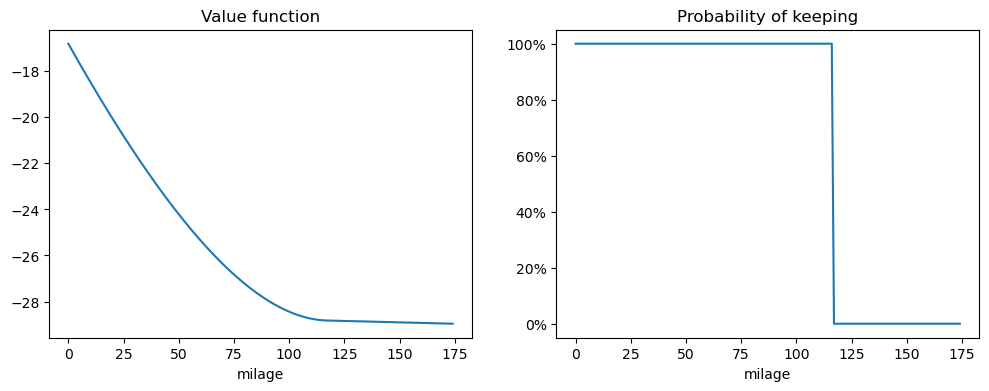

In [6]:
plot_solution(par, sol)

##### b) When is it now optimal to replace the engine? Is it different from before? Why, why not?
*Hint*: Are agents risk-averse?

**Answer.** The first replacement state remains grid point 117. With expected utility and no curvature in utility, the agent is risk neutral, so introducing mean-preserving uncertainty in mileage has little effect on this threshold here.

## Exercise 3 - Taste shocks (Monte Carlo Extreme value)

Now we change the assumption of observing all relevant characteristics. We assume that there are some states unobserved to the econometrician. In particular, we assume that there is a taste shock $ \epsilon $ for each choice that is unobserved to the econometrician and additively separable in the utility. 

We will assume that $ \epsilon $ is distributed according to the Extreme Value distribution type 1 (also called "Gumbel" distributed) given by the pdf $q(\cdot)$, is conditionally independent from $x$, and has support $Supp(\epsilon)=\Omega$. We can write the value function as

$$
V(x,\epsilon) = \max_{d\in \{0,1\}} \big\{ u(x,d) + \epsilon(d) + \beta
\underbrace{\sum_{X} \int_{\Omega} V(x',\epsilon') p(x'|x,d) q(\epsilon'|x')  d\epsilon' }_{EV(x,d)} \big\}
$$

Because of the taste shock today, choices are now stochastic. And also, we now have to handle the expectation of these taste shocks tommorow, which we can do by integrating them out.


In the lecture slides, this is written as a double-integral:
$$
V(x,\epsilon) = \max_{d\in \{0,1\}} \big\{ u(x,d) + \epsilon(d) + \beta
\underbrace{\int_{X} \int_{\Omega} V(x',\epsilon') \pi(x'|x,d) q(\epsilon'|x')  d\epsilon' dx' }_{EV(x,d)} \big\}
$$
We solve it using the integrated value function $\bar{V}(x)$ (see exercise class slides):
$$\bar{V}(x)=\int_{\Omega} \left[ \max_{d\in \{0,1 \}} \{ u(x,d)+\epsilon(d)+\beta \int_{X} \bar{V}(x')p(x'\vert x,d) dx'  \} \right] d\epsilon$$

We (later) use the Extreme Value type 1 distribution since it provides analytical expressions. The Extreme Value type 1 "looks similar" to the normal distribution:

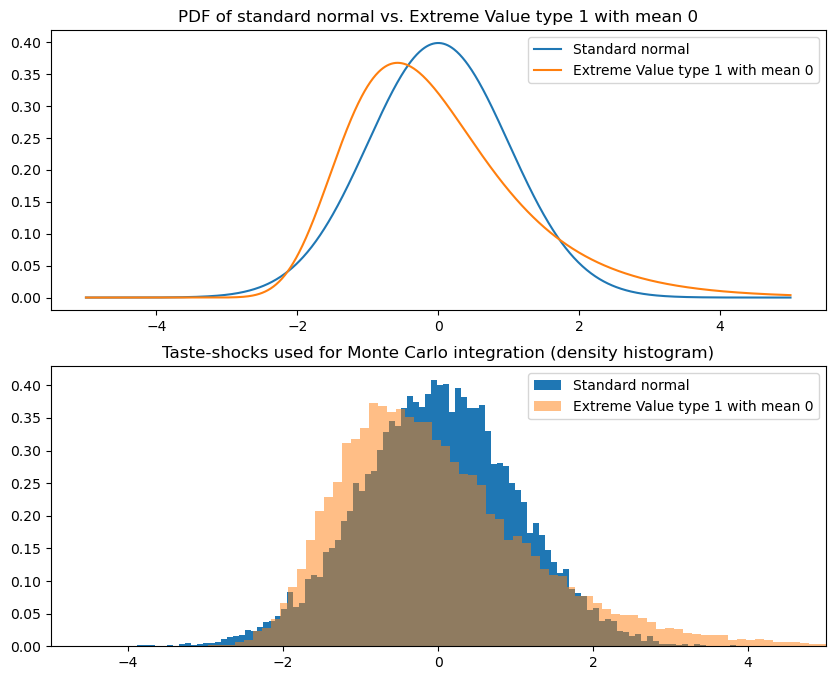

In [7]:
f, ax = plt.subplots(2,1,figsize=(10,8))

X = np.linspace(-5,5,1000)

ax[0].set_title('PDF of standard normal vs. Extreme Value type 1 with mean 0')
ax[0].plot(X, norm.pdf(X, loc=0, scale=1), label='Standard normal')
ax[0].plot(X, gumbel_r.pdf(X, loc=-np.euler_gamma, scale=1), label='Extreme Value type 1 with mean 0')
ax[0].legend()

ax[1].set_title('Taste-shocks used for Monte Carlo integration (density histogram)')
ax[1].hist(np.array([par.eps_keep_norm,par.eps_replace_norm]).flatten(), bins=100, label='Standard normal', density=True)
ax[1].hist(np.array([par.eps_keep_gumb,par.eps_replace_gumb]).flatten(), bins=100, alpha=0.5, label='Extreme Value type 1 with mean 0', density=True)
ax[1].set_xlim([-5,5])
ax[1].legend();

##### a) How should we interpret the taste-shocks?

**Answer.** They collect transitory choice-specific utility components observed by the decision maker but not by the econometrician—for example an unusually convenient or inconvenient time to replace the engine.

##### b) Solve the model with *Monte Carlo Extreme Value* shocks. Plot the solution. 

The code has been provided. This will take 20-60 seconds.

In [8]:
sol = model.solve_SA(par, stochastic_transition = True, taste_shocks = 'Monte Carlo: Extreme Value')

Finished after 1686 iterations
Convergence achieved: True


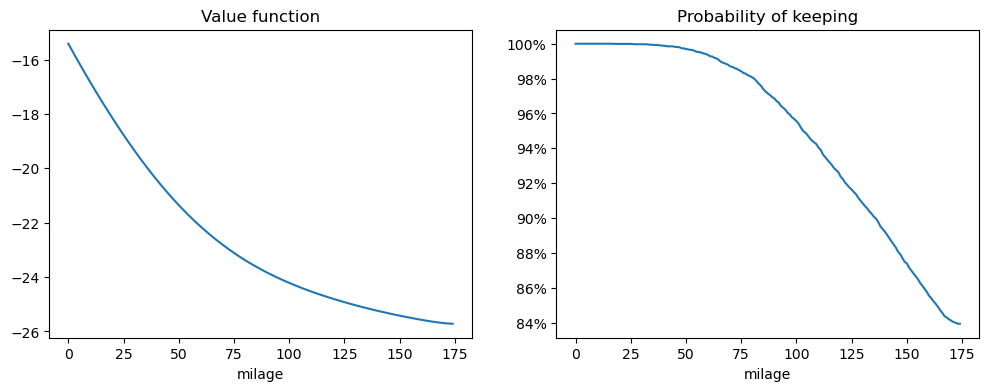

In [9]:
plot_solution(par, sol)

##### c) Why did the policy function change shape?

**Answer.** Choices are no longer deterministic conditional on mileage. Taste shocks smooth the sharp replacement threshold into a replacement probability that rises gradually with mileage.

#### d) If we were to add more choices, how computationally expensive do you expect this to be? Why?

**Answer.** Monte Carlo integration becomes expensive because every state, iteration, simulation draw, and additional choice must be evaluated. The work grows approximately linearly in the number of choices and draws.

## Exercise 4: Taste Shocks (Analytic Extreme Value)

In the previous exercise we used Monte Carlo simulation to integrate out the taste shocks. In this exercise, we will use some powerful properties of the extreme value distribution to analytically solve for the expected value.

*Hint*: Find the closed form solution of the expected value and choice probabilities in the lecture (or exercise class) slides.

##### a) Fill in the missing stuff in the $\texttt{bellman}$ function under *taste_shocks == 'Extreme Value'*. Solve the model and plot the solution.

In [10]:
sol = model.solve_SA(par, stochastic_transition = True, taste_shocks = 'Analytical: Extreme Value')

Finished after 1682 iterations


Convergence achieved: True


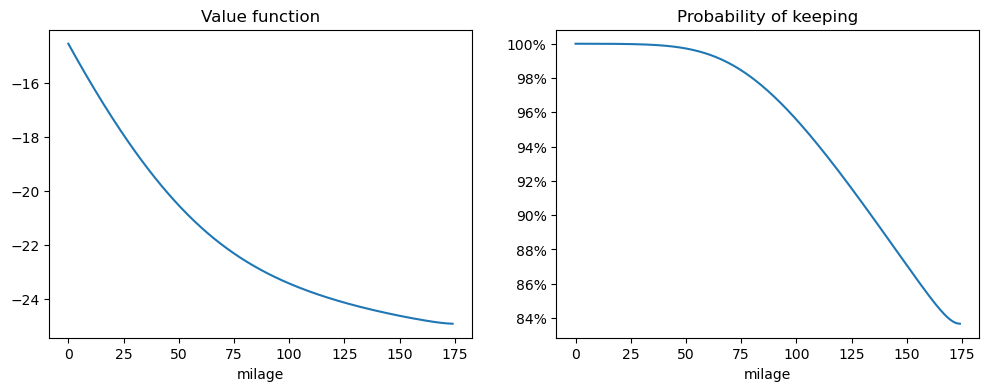

In [11]:
plot_solution(par, sol)

##### b) Are the solutions the same as with Monte Carlo? Why, why not?

**Answer.** They are very close but not numerically identical. The analytical log-sum solution is exact for Type-I extreme-value shocks, whereas the Monte Carlo solution contains finite-simulation error.

#### c) (Optional) Try to change the value of the scale parameter in the extreme-value distribution(sigma_eps in the code). What happens to the policy functions as the scale parameter goes to 0 or becomes very large? Set this back to 1.0 before proceeding.

**Answer.** As the scale approaches zero, the policy approaches the deterministic threshold rule. With a large scale, taste shocks dominate systematic utility differences and choice probabilities become flatter and closer to one half.

## Exercise 5 - Taste shocks (Normally distributed)

Now lets change the distributional assumption of the taste shocks. Let us now assume that the taste shocks are standard normally distributed.

##### a) Fill in the missing stuff in $\texttt{bellman}$ under *taste_shocks == 'Normal'*. Solve the model. Plot the solution.

In [12]:
sol = model.solve_SA(par, stochastic_transition = True, taste_shocks = 'Monte Carlo: Normal')

Finished after 1680 iterations
Convergence achieved: True


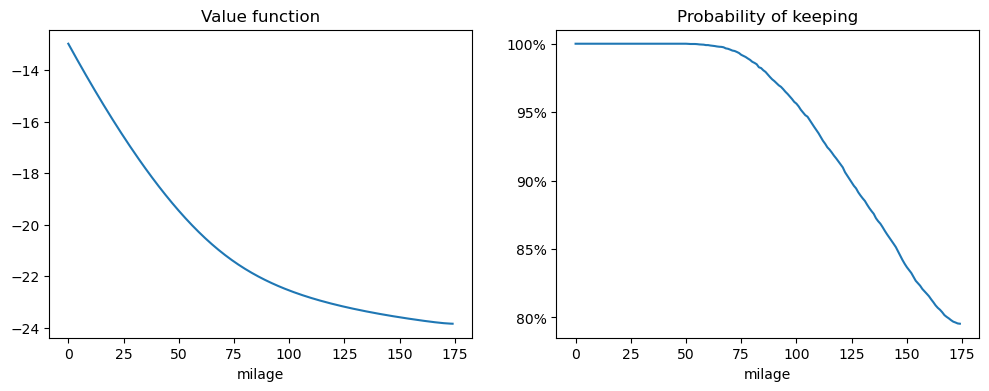

In [13]:
plot_solution(par, sol)

##### b) What is the advantage of assuming Extreme Value Type 1 taste shocks?

**Answer.** They yield closed-form log-sum expected values and logit choice probabilities, avoiding simulation or numerical integration over taste shocks.

## (Optional) Exercise 6 - Vectorized 

##### a) Solve the model in a vectorized form by filling out the missing stuff in the $\texttt{bellman\_vectorized}$ function. Plot the solution.

Assume that there are Extreme Value shocks and a stochastic state transition. You have been given the state transition matrices, which you will have to use.

In [14]:
sol = model.solve_SA(par, vectorized = True)

Finished after 1682 iterations
Convergence achieved: True


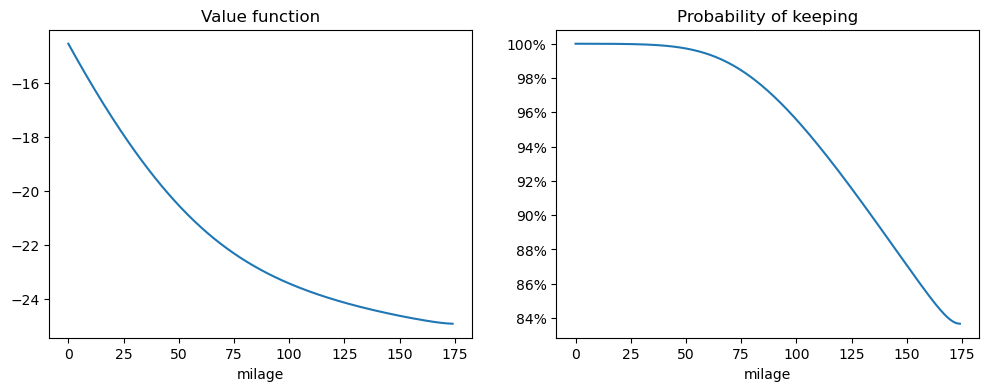

In [15]:
plot_solution(par, sol)

##### b) Are the results identical to the solution from exercise 4? What is the advantage of solving the model in a vectorized form?

**Answer.** Yes, up to numerical tolerance. Vectorization replaces Python loops with optimized array and matrix operations, making the Bellman operator much faster and more concise.